# 🏢 Enterprise HR Copilot
## Router Architecture using LangGraph + Groq

---

### 🏗️ Architecture: Router Pattern (Intent-Based Routing)

```
               Router
           /    |    |    \
      Payroll  Leave  Benefits  IT Support
```

**Flow:**
```
Employee Query
      ↓
  Router classifies intent
      ↓
  ONE specialist agent handles it
      ↓
  Response returned → END
```

**What each agent does:**
| Agent | Handles | Example Query |
|-------|---------|---------------|
| Router | Classifies intent → picks agent | (all queries) |
| Payroll Agent | Salary, tax, deductions, payslips | "When is payday?" |
| Leave Agent | PTO, sick leave, holidays, approval | "How many vacation days do I have?" |
| Benefits Agent | Health, insurance, retirement, perks | "How do I enroll in dental?" |
| IT Support Agent | Passwords, software, hardware, access | "My laptop won't connect to VPN" |

---

### 🔄 Router vs Supervisor — Key Difference

| Aspect | Supervisor (Project 1 & 2) | Router (This Project) |
|--------|---------------------------|------------------------|
| Agent execution | Sequential (all agents run) | Selective (ONE agent runs) |
| Decision timing | Between every step | Once at the start |
| Use case | Multi-step pipelines | Intent classification |
| Graph shape | Loop | Fan-out (one-shot) |
| Analogy | Project manager | Receptionist |

**Supervisor** = "Do step 1, then step 2, then step 3"  
**Router** = "Which department handles this? Go there directly."

---

### Step 0: Loading Environment & Liabraries

In [1]:
from dotenv import load_dotenv
load_dotenv()
import os

In [2]:
# pydantic: For structured data validation
from pydantic import BaseModel, Field

# LangChain components for prompts and parsing
from langchain_core.prompts import PromptTemplate
from langchain_core.output_parsers import StrOutputParser
from langchain_core.output_parsers import PydanticOutputParser

# LangChain message types
from langchain_core.messages import BaseMessage, HumanMessage, AIMessage

# LangChain runnable
from langchain_core.runnables import RunnablePassthrough

# LangGraph
from langgraph.graph import StateGraph, END

c:\Users\HP\anaconda3\envs\fresh_env\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


### Step 1: Loading/Initializing LLM

In [3]:
from langchain_groq import ChatGroq

# Groq automatically reads GROQ_API_KEY from environment variables

model = ChatGroq(
    model="openai/gpt-oss-120b",   # or llama-3.3-70b-versatile
    temperature=0.7
)

llm = model

In [4]:
# ---- TEST ----
try:
    response = llm.invoke("Say hello in one sentence.")
    print("✅ Groq LLM initialized successfully")
    print("Response:", response.content)

except Exception as e:
    print("❌ Groq LLM initialization failed")
    print(e)

✅ Groq LLM initialized successfully
Response: Hello! Hope you're having a wonderful day.


## 📋 Step 2 — Shared State Definition

**Key Insight:** Router Architecture state is SIMPLER than Supervisor.

In Supervisor pattern, state has many fields (one per agent output).  
In Router pattern, state has just:
- The input query
- The routing decision
- The final answer

```
State lifecycle:

START:    { query: "When is payday?",  route: "",         answer: None }
          ↓ Router runs
ROUTING:  { query: "When is payday?",  route: "payroll",  answer: None }
          ↓ Payroll Agent runs
END:      { query: "When is payday?",  route: "payroll",  answer: "Payday is..." }
```

In [6]:
from typing import TypedDict, Optional


class HRState(TypedDict):
    """
    Shared state for the HR Copilot routing pipeline.

    Much simpler than Supervisor state because:
    - Only ONE agent produces a final answer (not all of them)
    - No sequential accumulation of outputs
    - State is mostly read-only after routing decision is made
    """

    # --- Input ---
    # The employee's raw question exactly as typed
    query: str

    # --- Router Decision ---
    # The department the router assigns this query to.
    # Possible values: "payroll" | "leave" | "benefits" | "it_support" | "unknown"
    # "unknown" = router couldn't classify → fallback handler
    route: str

    # --- Agent Output ---
    # The final answer produced by whichever specialist agent was selected
    # Only ONE agent writes here (unlike Supervisor where multiple agents write)
    answer: Optional[str]

    # --- Metadata ---
    # Confidence score from the router (0.0 to 1.0)
    # Useful for logging, fallback triggers, or human escalation
    confidence: Optional[float]

    # Running log of events in this request's lifecycle
    messages: list


print("✅ HRState defined!")
print("   Fields:", list(HRState.__annotations__.keys()))
print()
print("   Compare with Supervisor state (Project 1):")
print("   Supervisor: company_name, financial_data, news_data, investment_memo, next_agent, messages")
print("   Router    : query, route, answer, confidence, messages  ← much simpler!")

✅ HRState defined!
   Fields: ['query', 'route', 'answer', 'confidence', 'messages']

   Compare with Supervisor state (Project 1):
   Supervisor: company_name, financial_data, news_data, investment_memo, next_agent, messages
   Router    : query, route, answer, confidence, messages  ← much simpler!


## 🗺️ Step 3 — The Router Agent (The Brain)

**This is the most important cell in Router Architecture.**

The Router's job: Read the query → classify intent → output a route string.

### How does it classify?
We use an LLM with a carefully structured prompt that:
1. Lists all available departments with examples
2. Asks for JSON output (structured, parseable)
3. Requests a confidence score (useful for escalation logic)
4. Handles ambiguous queries gracefully

### Why JSON output?
```
Bad  → LLM returns: "I think this should go to payroll"
Good → LLM returns: {"route": "payroll", "confidence": 0.95, "reason": "..."}
```
Structured output = reliable parsing = predictable routing.

In [9]:
import json
from langchain_groq import ChatGroq
from langchain_core.messages import HumanMessage, SystemMessage


def router_agent(state: dict) -> dict:
    """
    The Router: classifies employee query intent and assigns a department.

    This is the ONLY agent that runs for every query.
    After it runs, LangGraph's conditional edge picks the right specialist.

    Routing options:
      "payroll"    → salary, tax, deductions, payslips, bonuses
      "leave"      → PTO, sick days, holidays, leave approval, balance
      "benefits"   → health insurance, dental, retirement, perks, enrollment
      "it_support" → passwords, VPN, software, hardware, access, email
      "unknown"    → cannot classify → general fallback agent

    Args:
        state: HRState — reads 'query'

    Returns:
        Dict updating 'route', 'confidence', and 'messages'
    """
    print("\n" + "="*60)
    print("🗺️  ROUTER: Classifying employee query...")
    print("="*60)

    query = state["query"]
    print(f"   Query: \"{query}\"")

    # # We use a fast, cheap model for routing — it's a simple classification task
    # # No need to use the most powerful model here; save that for specialist agents
    # llm = ChatGroq(
    #     model="llama-3.3-70b-versatile",
    #     temperature=0,          # 0 = deterministic routing; we never want creative routing
    #     api_key=os.getenv("GROQ_API_KEY")
    # )

    # The routing prompt is the most critical prompt in Router Architecture.
    # Key design principles:
    #   1. Give the LLM a clear list of ALL valid routes
    #   2. Provide concrete examples per route (reduces ambiguity)
    #   3. Force JSON output for reliable parsing
    #   4. Ask for confidence — enables fallback/escalation logic
    #   5. Handle edge cases explicitly ("unknown" route)
    messages = [
        SystemMessage(content="""You are an HR routing system for an enterprise company.
Your ONLY job is to classify employee queries into exactly one department.

Available departments and what they handle:

1. "payroll"
   → salary, pay stub, paycheck, direct deposit, tax withholding,
     deductions, bonus, overtime pay, W-2, reimbursements

2. "leave"
   → vacation days, PTO, sick leave, maternity/paternity leave,
     leave balance, holiday schedule, leave approval, FMLA, bereavement

3. "benefits"
   → health insurance, dental, vision, life insurance, 401k,
     retirement plan, HSA, FSA, gym membership, employee perks,
     open enrollment, dependent coverage

4. "it_support"
   → password reset, VPN, laptop, software installation, email setup,
     system access, hardware issues, IT tickets, remote desktop,
     two-factor authentication

5. "unknown"
   → use ONLY when the query clearly doesn't fit any department above

You MUST respond with ONLY valid JSON in this exact format — no other text:
{
  "route": "<one of: payroll, leave, benefits, it_support, unknown>",
  "confidence": <float between 0.0 and 1.0>,
  "reason": "<one sentence explaining why you chose this department>"
}"""),

        HumanMessage(content=f"Employee query: {query}")
    ]

    response = llm.invoke(messages)
    raw_output = response.content.strip()

    # Parse the JSON response from the LLM
    # Always wrap JSON parsing in try/except — LLMs occasionally misbehave
    try:
        # Clean up in case LLM wraps output in markdown code fences
        # e.g., ```json { ... } ``` → { ... }
        cleaned = raw_output.replace("```json", "").replace("```", "").strip()
        routing_decision = json.loads(cleaned)

        route      = routing_decision.get("route", "unknown")
        confidence = routing_decision.get("confidence", 0.0)
        reason     = routing_decision.get("reason", "No reason provided")

    except json.JSONDecodeError:
        # Fallback if LLM doesn't return valid JSON
        # In production: log this, alert on-call, increment error counter
        print(f"   ⚠️  JSON parse failed. Raw output: {raw_output}")
        route      = "unknown"
        confidence = 0.0
        reason     = "Router failed to produce valid JSON"

    print(f"   Route      : {route}")
    print(f"   Confidence : {confidence:.0%}")
    print(f"   Reason     : {reason}")

    return {
        "route":      route,
        "confidence": confidence,
        "messages":   state["messages"] + [
            {"role": "router",
             "content": f"Routed to [{route}] with {confidence:.0%} confidence. Reason: {reason}"}
        ]
    }


print("✅ Router Agent defined!")
print()
print("   Key design decisions:")
print("   1. temperature=0       → deterministic, never random routing")
print("   2. JSON output         → reliable programmatic parsing")
print("   3. confidence score    → enables escalation/fallback logic")
print("   4. 'unknown' route     → graceful handling of out-of-scope queries")

✅ Router Agent defined!

   Key design decisions:
   1. temperature=0       → deterministic, never random routing
   2. JSON output         → reliable programmatic parsing
   3. confidence score    → enables escalation/fallback logic
   4. 'unknown' route     → graceful handling of out-of-scope queries


## 💰 Step 4 — Payroll Agent

**Role:** Answer questions about salary, payslips, tax, bonuses, deductions

**Key learning:** Each specialist agent has:
1. A focused **SystemMessage** defining its expertise
2. A **knowledge base** (simulated here as a string — in production this would be a RAG database)
3. Instructions to **escalate** when it can't answer (don't hallucinate!)

In [11]:
# Simulated company HR knowledge base for Payroll
# In production: this would be fetched from a database, HR system, or RAG pipeline
# For learning: we hardcode it so we can focus on the architecture
PAYROLL_KB = """
=== COMPANY PAYROLL POLICIES ===

Pay Schedule:
  - Employees are paid bi-weekly (every other Friday)
  - Direct deposit is processed 2 business days before payday
  - Paper checks are mailed 5 business days before payday

Pay Stubs:
  - Available on the HR portal (hr.company.com) under "My Pay"
  - Accessible 3 days before each payday
  - Historical pay stubs available for last 3 years

Tax Withholding:
  - Update W-4 anytime via HR portal → Tax Documents → Update W-4
  - Changes take effect within 2 pay cycles
  - State tax withholding updated separately under State Tax form

Bonuses:
  - Annual performance bonuses paid in February
  - Spot bonuses processed within 30 days of manager approval
  - Referral bonuses: $2,000 paid after referred employee completes 90 days

Deductions:
  - Health insurance, dental, vision: pre-tax deductions
  - 401k contributions: pre-tax, reflected on each paycheck
  - Questions about specific deductions: contact payroll@company.com

Reimbursements:
  - Submit expense reports via Concur within 30 days of expense
  - Approved reimbursements added to next regular paycheck
  - Same-day emergency reimbursement available for amounts over $500 (manager approval required)
"""


def payroll_agent(state: dict) -> dict:
    """
    Specialist Agent: Payroll
    Handles: salary, pay schedule, tax, deductions, bonuses, reimbursements

    Receives the employee's query + company policy knowledge base.
    Produces a clear, helpful, policy-grounded answer.
    """
    print("\n" + "="*60)
    print("💰 PAYROLL AGENT: Answering payroll query...")
    print("="*60)

    query = state["query"]
    print(f"   Query: \"{query}\"")

    # llm = ChatGroq(
    #     model="llama-3.3-70b-versatile",
    #     temperature=0.2,    # Slight warmth for friendly tone, but mostly factual
    #     api_key=os.getenv("GROQ_API_KEY")
    # )

    messages = [
        SystemMessage(content=f"""You are the Payroll department assistant for our company.
You answer employee questions about pay, salary, taxes, deductions, and reimbursements.

IMPORTANT RULES:
- Only answer based on the company policy provided below
- If the policy doesn't cover the question, say: "For this specific question,
  please contact payroll@company.com or call ext. 4400"
- Never guess or make up policy details
- Be friendly, concise, and actionable
- Always tell the employee what action to take next

COMPANY PAYROLL POLICY:
{PAYROLL_KB}"""),

        HumanMessage(content=query)
    ]

    response = llm.invoke(messages)
    print("   ✅ Payroll Agent answered!")

    return {
        "answer": response.content,
        "messages": state["messages"] + [
            {"role": "payroll_agent",
             "content": "Payroll query answered."}
        ]
    }


print("✅ Payroll Agent defined!")

✅ Payroll Agent defined!


## 🏖️ Step 5 — Leave Agent

**Role:** Answer questions about PTO, sick leave, holidays, leave approval, balance

In [13]:
LEAVE_KB = """
=== COMPANY LEAVE POLICIES ===

Annual Leave (PTO):
  - 0-2 years tenure   : 15 days/year
  - 3-5 years tenure   : 20 days/year
  - 6+ years tenure    : 25 days/year
  - PTO accrues monthly (1/12 of annual allowance per month)
  - Maximum rollover   : 5 days to next year; rest expires Dec 31

Sick Leave:
  - 10 sick days per year (non-accruing, refreshed Jan 1)
  - Does not roll over to next year
  - Doctor's note required for absences longer than 3 consecutive days

Public Holidays:
  - 12 federal holidays observed + 2 floating holidays (employee's choice)
  - Holiday schedule published on HR portal in November each year
  - Working on a public holiday: 1.5x pay OR comp day off (manager approval)

Leave Approval Process:
  - PTO requests: submit in HR portal at least 2 weeks in advance
  - Emergency leave: notify manager by phone/text ASAP, then log in portal
  - Leave approval: manager has 3 business days to approve/deny
  - Denied leave: appeal to HR Business Partner within 5 business days

Special Leave:
  - Maternity leave  : 16 weeks fully paid
  - Paternity leave  : 6 weeks fully paid
  - Bereavement      : 5 days (immediate family), 3 days (extended family)
  - Jury duty        : fully paid for duration
  - FMLA             : up to 12 weeks unpaid, job protected (federal law)

Leave Balance:
  - Check current balance: HR Portal → My Leave → Leave Balance
  - Balance updates within 24 hours of approved leave
"""


def leave_agent(state: dict) -> dict:
    """
    Specialist Agent: Leave Management
    Handles: PTO, sick leave, maternity/paternity, holidays, approval process
    """
    print("\n" + "="*60)
    print("🏖️  LEAVE AGENT: Answering leave query...")
    print("="*60)

    query = state["query"]
    print(f"   Query: \"{query}\"")

    # llm = ChatGroq(
    #     model="llama-3.3-70b-versatile",
    #     temperature=0.2,
    #     api_key=os.getenv("GROQ_API_KEY")
    # )

    messages = [
        SystemMessage(content=f"""You are the Leave Management assistant for our company.
You answer employee questions about PTO, sick leave, holidays, and leave approval.

IMPORTANT RULES:
- Answer only based on the company leave policy below
- If the employee's tenure affects their entitlement, ask for it politely
- If the policy doesn't cover the question, direct them to: hr@company.com or ext. 4401
- Be empathetic — leave questions are often personal and time-sensitive
- Always tell the employee the exact steps to take action

COMPANY LEAVE POLICY:
{LEAVE_KB}"""),

        HumanMessage(content=query)
    ]

    response = llm.invoke(messages)
    print("   ✅ Leave Agent answered!")

    return {
        "answer": response.content,
        "messages": state["messages"] + [
            {"role": "leave_agent",
             "content": "Leave query answered."}
        ]
    }


print("✅ Leave Agent defined!")

✅ Leave Agent defined!


## 🏥 Step 6 — Benefits Agent

**Role:** Answer questions about health insurance, dental, 401k, perks, enrollment

In [14]:
BENEFITS_KB = """
=== COMPANY BENEFITS POLICIES ===

Health Insurance:
  Plans offered:
    - PPO Gold   : $150/month employee, $400/month family. Low deductible ($500)
    - PPO Silver : $80/month employee, $220/month family. Medium deductible ($1,500)
    - HMO Basic  : $30/month employee, $100/month family. High deductible ($3,000)
  Company covers 70% of premium cost for all plans.
  Enrollment: Open enrollment in November for January 1 coverage.
  New hire enrollment: within 30 days of start date.

Dental & Vision:
  - Dental: 2 cleanings/year covered 100%. Major work covered 60% after $50 deductible.
  - Vision: 1 eye exam/year + $150 frames/lenses allowance. Coverage resets Jan 1.
  - Combined dental+vision: $25/month employee contribution

Retirement (401k):
  - Company match: 100% of first 4% of salary contributed
  - Vesting schedule: 25% per year, fully vested at 4 years
  - 2024 contribution limit: $23,000 (IRS limit); $30,500 if age 50+
  - Change contribution: HR Portal → Benefits → 401k → Change Contribution
  - Investment options: 20 funds available, including target-date funds

Additional Perks:
  - Gym/Wellness : $50/month reimbursement (submit receipts via HR portal)
  - Learning     : $2,000/year education assistance for approved courses
  - EAP          : Free confidential counseling — 8 sessions/year, call 1-800-EAP-HELP
  - Commuter     : Pre-tax transit/parking up to $315/month
  - Life Insurance: 2x annual salary, company paid. Optional add-on available.

Open Enrollment:
  - Annual window: November 1-30 for next calendar year
  - Changes outside enrollment: only allowed for qualifying life events
    (marriage, birth, divorce, loss of other coverage)
  - Contact: benefits@company.com or call 1-888-HR-BENES
"""


def benefits_agent(state: dict) -> dict:
    """
    Specialist Agent: Benefits
    Handles: health/dental/vision insurance, 401k, perks, enrollment
    """
    print("\n" + "="*60)
    print("🏥 BENEFITS AGENT: Answering benefits query...")
    print("="*60)

    query = state["query"]
    print(f"   Query: \"{query}\"")

    # llm = ChatGroq(
    #     model="llama-3.3-70b-versatile",
    #     temperature=0.2,
    #     api_key=os.getenv("GROQ_API_KEY")
    # )

    messages = [
        SystemMessage(content=f"""You are the Employee Benefits assistant for our company.
You answer questions about health insurance, dental, vision, 401k, and company perks.

IMPORTANT RULES:
- Answer only based on the benefits policy below
- When discussing insurance, always mention costs clearly
- If open enrollment timing matters, highlight it prominently
- For 401k questions, always mention the company match — it's valuable!
- If the policy doesn't cover the question: benefits@company.com or 1-888-HR-BENES
- Be clear and structured — use bullet points for plan comparisons

COMPANY BENEFITS POLICY:
{BENEFITS_KB}"""),

        HumanMessage(content=query)
    ]

    response = llm.invoke(messages)
    print("   ✅ Benefits Agent answered!")

    return {
        "answer": response.content,
        "messages": state["messages"] + [
            {"role": "benefits_agent",
             "content": "Benefits query answered."}
        ]
    }


print("✅ Benefits Agent defined!")

✅ Benefits Agent defined!


## 💻 Step 7 — IT Support Agent

**Role:** Handle password resets, VPN issues, software, hardware, access requests

**Special feature:** IT queries often need **specific step-by-step instructions** — notice how the system prompt emphasizes numbered steps.

In [15]:
IT_KB = """
=== IT SUPPORT KNOWLEDGE BASE ===

Password Reset:
  Self-service (fastest):
    1. Go to password.company.com
    2. Click "Forgot Password"
    3. Enter your employee email
    4. Check phone for SMS code
    5. Set new password (min 12 chars, 1 uppercase, 1 number, 1 symbol)
  If locked out: call IT helpdesk at ext. 5000 (24/7)

VPN Access:
  Setup:
    1. Download Cisco AnyConnect from software.company.com/vpn
    2. Server: vpn.company.com
    3. Use your company email + password
    4. Accept the MFA push notification on your phone
  Troubleshooting:
    - "Connection failed": ensure you're not already on company WiFi
    - "Authentication error": check MFA app is synced (time-based)
    - Still failing: raise ticket at tickets.company.com

Software Installation:
  - Approved software list: software.company.com/catalog
  - Self-install from Software Center (Windows) or Self Service (Mac)
  - Software not in catalog: submit request at tickets.company.com (3-5 day approval)
  - Adobe, Microsoft Office, Slack, Zoom: pre-installed on all laptops

Hardware Issues:
  - Laptop won't start: hold power button 10 seconds, then restart
  - Peripheral issues (keyboard/mouse): try different USB port first
  - Hardware replacement: raise P2 ticket, loan device available same-day
  - New equipment requests: manager approval + 5-7 business days delivery

Email & Accounts:
  - New email/account setup: auto-provisioned on day 1 via IT onboarding
  - Distribution list requests: tickets.company.com → Account Management
  - Shared mailbox access: manager submits request via IT portal
  - Email storage limit: 100GB. Archive old emails via Outlook Archive tool

IT Helpdesk:
  - Phone: ext. 5000 (24/7 for critical issues)
  - Chat: it-support channel in Slack (9am-6pm Mon-Fri)
  - Ticket: tickets.company.com (all non-urgent requests)
  - Priority levels: P1=system down, P2=major disruption, P3=minor issue
"""


def it_support_agent(state: dict) -> dict:
    """
    Specialist Agent: IT Support
    Handles: passwords, VPN, software, hardware, email, system access
    """
    print("\n" + "="*60)
    print("💻 IT SUPPORT AGENT: Answering IT query...")
    print("="*60)

    query = state["query"]
    print(f"   Query: \"{query}\"")

    # llm = ChatGroq(
    #     model="llama-3.3-70b-versatile",
    #     temperature=0.1,    # Very low — IT instructions must be precise and exact
    #     api_key=os.getenv("GROQ_API_KEY")
    # )

    messages = [
        SystemMessage(content=f"""You are the IT Support assistant for our company.
You help employees with technical issues: passwords, VPN, software, hardware, and access.

IMPORTANT RULES:
- Answer only based on the IT knowledge base below
- ALWAYS provide step-by-step numbered instructions for technical procedures
- Mention self-service options first (fastest for the employee)
- Include specific URLs, extension numbers, and contact channels
- If the issue could be urgent (system down, can't work), mention P1 escalation
- If KB doesn't cover it: tickets.company.com or ext. 5000

IT KNOWLEDGE BASE:
{IT_KB}"""),

        HumanMessage(content=query)
    ]

    response = llm.invoke(messages)
    print("   ✅ IT Support Agent answered!")

    return {
        "answer": response.content,
        "messages": state["messages"] + [
            {"role": "it_support_agent",
             "content": "IT query answered."}
        ]
    }


print("✅ IT Support Agent defined!")

✅ IT Support Agent defined!


## ❓ Step 8 — Unknown/Fallback Agent

**Role:** Handle queries that don't fit any department

**Why this matters:** In production systems, ~5-10% of queries are ambiguous or out-of-scope.
A good Router Architecture **always** has a graceful fallback — never leave users hanging.

The fallback agent:
- Acknowledges it can't fully answer
- Tries to partially help anyway
- Provides a human escalation path

In [16]:
def unknown_agent(state: dict) -> dict:
    """
    Fallback Agent: Handles unclassifiable or out-of-scope queries.

    IMPORTANT: Never just say "I don't know" — always:
    1. Acknowledge the query
    2. Explain what departments ARE available
    3. Suggest the best path forward (human HR contact)
    4. Try to partially help if possible

    In production, this agent would also:
    - Log the unhandled query for product improvement
    - Trigger a human-in-the-loop review
    - Potentially ask a clarifying question to re-route
    """
    print("\n" + "="*60)
    print("❓ UNKNOWN AGENT: Handling unclassified query...")
    print("="*60)

    query = state["query"]
    print(f"   Query: \"{query}\"")

    # llm = ChatGroq(
    #     model="llama-3.3-70b-versatile",
    #     temperature=0.3,
    #     api_key=os.getenv("GROQ_API_KEY")
    # )

    messages = [
        SystemMessage(content="""You are a general HR assistant. An employee has asked
a question that doesn't clearly fit into Payroll, Leave, Benefits, or IT Support.

Your job:
1. Warmly acknowledge their question
2. Be honest that this may need a human HR specialist
3. Tell them what our HR system CAN help with (Payroll, Leave, Benefits, IT)
4. Provide the general HR contact: hr@company.com or call ext. 4400 (Mon-Fri 9-5)
5. If their question partially overlaps with any department, mention it

Be warm and helpful, not robotic."""),

        HumanMessage(content=f"Employee asked: {query}")
    ]

    response = llm.invoke(messages)
    print("   ✅ Unknown Agent responded with fallback!")

    return {
        "answer": response.content,
        "messages": state["messages"] + [
            {"role": "unknown_agent",
             "content": "Query couldn't be classified. Fallback response provided."}
        ]
    }


print("✅ Unknown/Fallback Agent defined!")
print()
print("   Why fallback matters:")
print("   ~5-10% of real queries are ambiguous or out-of-scope.")
print("   Without a fallback, users get a crash or silent failure.")

✅ Unknown/Fallback Agent defined!

   Why fallback matters:
   ~5-10% of real queries are ambiguous or out-of-scope.
   Without a fallback, users get a crash or silent failure.


## 🕸️ Cell 10 — Build the LangGraph (Router Architecture)

**This is where Router Architecture differs from Supervisor Architecture.**

```
Supervisor Graph (Project 1 & 2):     Router Graph (This Project):

START → supervisor                    START → router
  ↓ (conditional — loops back)          ↓ (conditional — fan-out, no loop!)
  agent_A → supervisor                  ├── payroll_agent  → END
  agent_B → supervisor                  ├── leave_agent    → END
  agent_C → supervisor                  ├── benefits_agent → END
  END ←────────────────                 ├── it_support_agent → END
                                        └── unknown_agent  → END
```

**Key difference:** In Router, specialist agents connect directly to END.
There's NO loop back to the router. One query → one agent → done.

In [17]:
from langgraph.graph import StateGraph, END as GRAPH_END


def route_query(state: dict) -> str:
    """
    Routing function for LangGraph's conditional edges.

    Called AFTER router_agent runs.
    Reads the 'route' field from state and returns the node name to go to.

    This is a pure pass-through — the actual routing decision
    was already made by the LLM inside router_agent().

    Returns:
        Node name string that LangGraph will route to next
    """
    route = state.get("route", "unknown")
    print(f"   🔀 Conditional Edge: routing to → {route}")
    return route


def build_hr_graph():
    """
    Build the HR Copilot routing graph.

    Structure:
      1 router node → conditional edges → 5 specialist nodes → END

    This is a DIRECTED ACYCLIC GRAPH (DAG) — no loops.
    Compare with Supervisor which is a CYCLIC graph (with loops).
    """

    # 1. Initialize graph with our state schema
    graph = StateGraph(HRState)

    # 2. Register ALL nodes
    #    Each agent function becomes a callable node
    graph.add_node("router",          router_agent)      # Entry point: classifies intent
    graph.add_node("payroll",         payroll_agent)     # Handles payroll queries
    graph.add_node("leave",           leave_agent)       # Handles leave queries
    graph.add_node("benefits",        benefits_agent)    # Handles benefits queries
    graph.add_node("it_support",      it_support_agent)  # Handles IT queries
    graph.add_node("unknown",         unknown_agent)     # Fallback for unclassified

    # 3. Set entry point — every query starts at the router
    graph.set_entry_point("router")

    # 4. Conditional edges FROM router → specialist agents
    #
    #    After router_agent() runs and writes state["route"],
    #    route_query() reads it and returns the matching node name.
    #
    #    The dict maps route_query() return values → node names.
    #    This is how LangGraph knows WHERE to send the request.
    graph.add_conditional_edges(
        "router",           # FROM: router node
        route_query,        # FUNCTION: reads state["route"] and returns it
        {                   # MAPPING: return value → node name
            "payroll":    "payroll",
            "leave":      "leave",
            "benefits":   "benefits",
            "it_support": "it_support",
            "unknown":    "unknown",
        }
    )

    # 5. Each specialist agent connects DIRECTLY to END
    #
    #    KEY DIFFERENCE from Supervisor Architecture:
    #    - Supervisor: agent → supervisor (loop back)
    #    - Router:     agent → END (no loop, one shot per query)
    graph.add_edge("payroll",    GRAPH_END)
    graph.add_edge("leave",      GRAPH_END)
    graph.add_edge("benefits",   GRAPH_END)
    graph.add_edge("it_support", GRAPH_END)
    graph.add_edge("unknown",    GRAPH_END)

    # 6. Compile → validates structure, returns runnable app
    app = graph.compile()

    print("✅ HR Copilot Graph compiled!")
    print()
    print("   Graph structure:")
    print("   START → router → [payroll|leave|benefits|it_support|unknown] → END")
    print()
    print("   This is a fan-out graph (not a loop like Supervisor).")
    print("   Every query: 2 LLM calls max (router + 1 specialist).")

    return app


# Build the app
app = build_hr_graph()

✅ HR Copilot Graph compiled!

   Graph structure:
   START → router → [payroll|leave|benefits|it_support|unknown] → END

   This is a fan-out graph (not a loop like Supervisor).
   Every query: 2 LLM calls max (router + 1 specialist).


## (Optional) Visualize the Graph

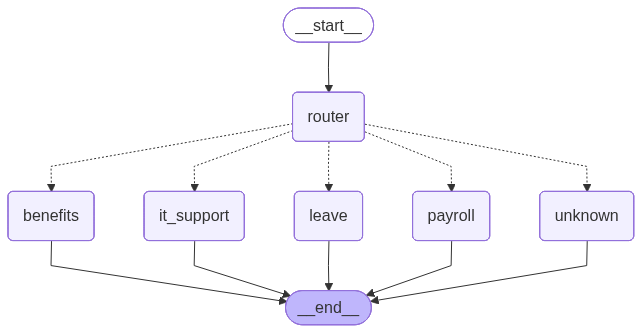

In [18]:
# Display graph visually
# Requires: pip install grandalf
try:
    from IPython.display import Image, display
    display(Image(app.get_graph().draw_mermaid_png()))
except Exception:
    # Fallback: Mermaid text (paste at https://mermaid.live)
    print("Mermaid diagram (paste at https://mermaid.live to visualize):")
    print(app.get_graph().draw_mermaid())

## 🔧 Step 10 — The Helper Runner Function

A clean wrapper so we can test multiple queries easily in subsequent cells.

In [19]:
from IPython.display import Markdown, display


def ask_hr(query: str, show_routing: bool = True) -> dict:
    """
    Ask the HR Copilot a question.

    This is the main entry point employees would use.
    Wraps the LangGraph invocation with clean input/output formatting.

    Args:
        query       : The employee's question in plain English
        show_routing: Whether to show routing decision details

    Returns:
        final_state dict with 'route', 'answer', 'confidence'
    """

    print("\n" + "🤔 " + "="*57)
    print(f"   EMPLOYEE QUERY: {query}")
    print("="*60)

    # Build the initial state with just the query
    # Everything else starts empty — agents fill it in
    initial_state = {
        "query":      query,
        "route":      "",       # Router fills this
        "answer":     None,     # Specialist agent fills this
        "confidence": None,     # Router fills this
        "messages":   [
            {"role": "employee", "content": query}
        ]
    }

    # Run the graph — router picks agent, agent answers, done
    final_state = app.invoke(initial_state)

    # Display results
    print("\n" + "="*60)
    print("✅ HR COPILOT RESPONSE")
    print("="*60)

    if show_routing:
        dept_emoji = {
            "payroll":    "💰",
            "leave":      "🏖️",
            "benefits":   "🏥",
            "it_support": "💻",
            "unknown":    "❓"
        }
        emoji = dept_emoji.get(final_state['route'], "🤖")
        print(f"   Routed to  : {emoji} {final_state['route'].upper()} department")
        print(f"   Confidence : {final_state.get('confidence', 0):.0%}")
        print()

    print("📋 ANSWER:")
    print("-" * 60)
    # Render Markdown for nicely formatted responses
    display(Markdown(final_state.get("answer", "No answer generated.")))

    return final_state


print("✅ ask_hr() helper defined!")
print("   Usage: result = ask_hr('When is payday?')")

✅ ask_hr() helper defined!
   Usage: result = ask_hr('When is payday?')


## 🚀 Step 11 — Test: Payroll Query

Expected route: `payroll`

In [20]:
result = ask_hr("When do we get paid this month and how can I view my pay stub?")


🤔 =========================================================
   EMPLOYEE QUERY: When do we get paid this month and how can I view my pay stub?

🗺️  ROUTER: Classifying employee query...
   Query: "When do we get paid this month and how can I view my pay stub?"
   Route      : payroll
   Confidence : 99%
   Reason     : The query asks about pay dates and viewing a pay stub, which are payroll matters.
   🔀 Conditional Edge: routing to → payroll

💰 PAYROLL AGENT: Answering payroll query...
   Query: "When do we get paid this month and how can I view my pay stub?"
   ✅ Payroll Agent answered!

✅ HR COPILOT RESPONSE
   Routed to  : 💰 PAYROLL department
   Confidence : 99%

📋 ANSWER:
------------------------------------------------------------


**Pay dates this month**  
- Our bi‑weekly schedule lands on **Friday, March 13** and **Friday, March 27**. (Paychecks are issued the Friday of each pay period.)

**How to view your pay stub**  
1. Log in to the HR portal at **hr.company.com**.  
2. Click **“My Pay.”**  
3. Your current pay stub will be available **3 business days before each payday** (so you’ll see the March 13 stub on or after Monday, March 9, and the March 27 stub on or after Monday, March 23).  
4. Historical stubs for the past three years are also stored there.

**Next steps**  
- If you need the exact amount or have any issues accessing the portal, please reach out to **payroll@company.com** or call **ext. 4400**.

## 🚀 Step 12 — Test: Leave Query

Expected route: `leave`

In [21]:
result = ask_hr("I just found out I'm pregnant! How much maternity leave do I get and is it paid?")


🤔 =========================================================
   EMPLOYEE QUERY: I just found out I'm pregnant! How much maternity leave do I get and is it paid?

🗺️  ROUTER: Classifying employee query...
   Query: "I just found out I'm pregnant! How much maternity leave do I get and is it paid?"
   Route      : leave
   Confidence : 99%
   Reason     : The query asks about maternity leave duration and pay, which falls under the leave department.
   🔀 Conditional Edge: routing to → leave

🏖️  LEAVE AGENT: Answering leave query...
   Query: "I just found out I'm pregnant! How much maternity leave do I get and is it paid?"
   ✅ Leave Agent answered!

✅ HR COPILOT RESPONSE
   Routed to  : 🏖️ LEAVE department
   Confidence : 99%

📋 ANSWER:
------------------------------------------------------------


Congratulations on your news! 🎉  

**Maternity leave:**  
- **Duration:** 16 weeks  
- **Pay:** Fully paid (you will receive your regular salary for the entire 16‑week period)

**How to get it started**

1. **Notify your manager** as soon as you’re comfortable – let them know you’ll be taking maternity leave and discuss any tentative dates.  
2. **Submit a formal leave request** in the HR portal:  
   - Go to **HR Portal → My Leave → Request Leave**  
   - Choose **“Maternity Leave”** from the leave‑type dropdown  
   - Enter your planned start and end dates (you can adjust later if needed)  
   - Attach any required documentation (e.g., a doctor’s note confirming your pregnancy, if requested).  
3. **Manager approval:** Your manager has up to 3 business days to approve or deny the request.  
4. **HR confirmation:** Once approved, HR will update your leave balance and confirm the pay schedule within 24 hours.  

**Next steps for you**

- If you’re unsure about the exact dates, you can submit a **tentative** request now and update it later once your due date is clearer.  
- Keep an eye on the **Leave Balance** page (HR Portal → My Leave → Leave Balance) to see the approved leave reflected.  

If you run into any issues or have additional questions (e.g., about benefits continuation, paperwork, or timing), please reach out to **HR Business Partner** at **hr@company.com** or call **ext. 4401**.  

Wishing you a smooth and healthy pregnancy! 🌟

## 🚀 Step 13 — Test: Benefits Query

Expected route: `benefits`

In [22]:
result = ask_hr("I want to start contributing to my 401k. Does the company match my contributions?")


🤔 =========================================================
   EMPLOYEE QUERY: I want to start contributing to my 401k. Does the company match my contributions?

🗺️  ROUTER: Classifying employee query...
   Query: "I want to start contributing to my 401k. Does the company match my contributions?"
   Route      : benefits
   Confidence : 99%
   Reason     : The query asks about 401k contributions and matching, which are handled by the benefits department.
   🔀 Conditional Edge: routing to → benefits

🏥 BENEFITS AGENT: Answering benefits query...
   Query: "I want to start contributing to my 401k. Does the company match my contributions?"
   ✅ Benefits Agent answered!

✅ HR COPILOT RESPONSE
   Routed to  : 🏥 BENEFITS department
   Confidence : 99%

📋 ANSWER:
------------------------------------------------------------


**Yes – the company matches your 401(k) contributions!**

- **Match details**
  - The company matches **100 % of the first 4 % of your salary** that you contribute.
  - Example: If you earn $70,000 and contribute 4 % ($2,800), the company adds another $2,800.

- **How to start contributing**
  1. Log in to the **HR Portal**.  
  2. Navigate to **Benefits → 401(k) → Change Contribution**.  
  3. Enter the percentage of salary you want to defer (up to the IRS limit).  
  4. Save the changes – the contribution will be taken from your next payroll cycle.

- **Contribution limits for 2024**
  - $23,000 total employee contribution (IRS limit).  
  - If you are age 50 or older, you can contribute up to $30,500 (includes catch‑up).

- **Why it’s valuable**
  - The match is essentially “free money” that instantly boosts your retirement savings.  
  - Combined with the vesting schedule (25 % per year, fully vested after 4 years), you’ll own the full match after four years of service.

If you have any trouble accessing the portal or need help selecting an investment fund, contact **benefits@company.com** or call **1‑888‑HR‑BENES**.

## 🚀 Step 14— Test: IT Support Query

Expected route: `it_support`

In [23]:
result = ask_hr("I can't connect to VPN from home. I'm getting an authentication error. Help!")


🤔 =========================================================
   EMPLOYEE QUERY: I can't connect to VPN from home. I'm getting an authentication error. Help!

🗺️  ROUTER: Classifying employee query...
   Query: "I can't connect to VPN from home. I'm getting an authentication error. Help!"
   Route      : it_support
   Confidence : 99%
   Reason     : The employee is experiencing a VPN connection/authentication issue, which falls under IT support.
   🔀 Conditional Edge: routing to → it_support

💻 IT SUPPORT AGENT: Answering IT query...
   Query: "I can't connect to VPN from home. I'm getting an authentication error. Help!"
   ✅ IT Support Agent answered!

✅ HR COPILOT RESPONSE
   Routed to  : 💻 IT_SUPPORT department
   Confidence : 99%

📋 ANSWER:
------------------------------------------------------------


**Quick self‑service steps (fastest way to fix the VPN authentication error)**  

1. **Make sure you’re not connected to the corporate Wi‑Fi** – the VPN client will reject the connection if it detects you’re already on the internal network.  
2. **Open the MFA app on your phone** (Microsoft Authenticator, Duo, etc.) and verify that the time is correct:  
   a. In the app settings enable **“Auto‑sync time”** or **“Time‑based one‑time password (TOTP) sync”**.  
   b. If the app shows the wrong time, force a sync (usually a “Refresh” or “Sync now” button).  
3. **Close and reopen Cisco AnyConnect**:  
   a. Click the **X** to exit the client.  
   b. Re‑launch it from the Start menu (Windows) or Applications folder (Mac).  
4. **Attempt to connect again**:  
   - Server: `vpn.company.com`  
   - Username: your company email address  
   - Password: your current AD password  
   - When prompted, **approve the MFA push** on your phone.  

If the authentication error disappears, you’re back online.  

---

### If the problem persists

1. **Double‑check your credentials** – make sure your password isn’t expired or locked (you can reset it quickly via the self‑service portal: `https://password.company.com`).  
2. **Verify the AnyConnect client version** – download the latest installer from `https://software.company.com/vpn` and reinstall if you’re using an older build.  
3. **Run a network test**: open a web browser and try to reach `https://vpn.company.com`. If you get a certificate warning or “site can’t be reached”, there may be a local network block (e.g., ISP firewall). Try a different home network or a mobile hotspot.  

---

### When you need further help

- **Raise a ticket** (non‑urgent):  
  - Go to **`https://tickets.company.com`** and select **“VPN – Authentication Error”**.  
  - Attach a screenshot of the error message and note the steps you’ve already tried.  
- **Urgent / cannot work**: This is a **P1**‑type impact (you’re unable to access corporate resources).  
  - Call the IT Helpdesk **ext. 5000** (24/7) and state “P1 – VPN authentication error, need immediate assistance”.  
  - You can also message the **#it-support** channel in Slack (available 9 am‑6 pm Mon‑Fri) for a rapid response.  

A support engineer will verify your MFA enrollment, reset the token if needed, or provide a temporary access token while the root cause is investigated.  

---  

**Summary of contacts & URLs**

| Action | URL / Contact |
|--------|---------------|
| Password reset (if needed) | `https://password.company.com` |
| VPN client download | `https://software.company.com/vpn` |
| Ticket submission | `https://tickets.company.com` |
| Phone (P1 escalation) | **ext. 5000** (24/7) |
| Slack chat | **#it-support** (9 am‑6 pm Mon‑Fri) |

If after following the self‑service steps you still can’t authenticate, please open a ticket or call ext. 5000 right away so we can treat this as a P1 incident.

## 🚀 Step 15 — Test: Ambiguous Query (Tests Router Intelligence)

This query mentions BOTH payroll AND benefits — which does the router pick?

Expected route: `benefits` (dental = benefits domain) or `payroll` (deduction = payroll domain)  
This is a great test to see how the router handles ambiguity!

In [24]:
result = ask_hr("Why is there a dental deduction on my paycheck? I didn't sign up for dental insurance.")


🤔 =========================================================
   EMPLOYEE QUERY: Why is there a dental deduction on my paycheck? I didn't sign up for dental insurance.

🗺️  ROUTER: Classifying employee query...
   Query: "Why is there a dental deduction on my paycheck? I didn't sign up for dental insurance."
   Route      : benefits
   Confidence : 92%
   Reason     : The query concerns an unexpected dental insurance deduction, which relates to health benefits enrollment and coverage.
   🔀 Conditional Edge: routing to → benefits

🏥 BENEFITS AGENT: Answering benefits query...
   Query: "Why is there a dental deduction on my paycheck? I didn't sign up for dental insurance."
   ✅ Benefits Agent answered!

✅ HR COPILOT RESPONSE
   Routed to  : 🏥 BENEFITS department
   Confidence : 92%

📋 ANSWER:
------------------------------------------------------------


**What’s likely happening**

- **Combined Dental + Vision plan** – The only way dental coverage is added to payroll is through the optional **combined dental + vision plan** ($25 per month employee contribution).  
- **Automatic enrollment** – When you first enrolled in benefits (or during a recent open‑enrollment window), the system may have default‑selected this plan for you unless you explicitly opted out.  

**What to do next**

1. **Check your Benefits portal**  
   - Log in to the HR portal → **Benefits** → **Current Elections**.  
   - Look for “Dental + Vision – $25/month” under the “Dental & Vision” section.  

2. **If you didn’t choose it**  
   - You can **remove the election** now (if you’re still within the open‑enrollment period: **Nov 1‑30**) or wait for the next open‑enrollment window.  
   - If you need to change it outside the window, you’ll need a **qualifying life event** (e.g., loss of other coverage).  

3. **Contact HR for help**  
   - **Email:** benefits@company.com  
   - **Phone:** 1‑888‑HR‑BENES  
   - Mention the unexpected dental deduction and ask them to verify whether you were enrolled automatically and to process a removal if desired.  

**Quick reminder**

- **Open enrollment** for the next plan year runs **Nov 1‑30**. Any changes you want to make for the upcoming year should be submitted during that window.  
- If you *do* want dental coverage later, you can enroll during open enrollment or after a qualifying life event.  

Let me know if you need step‑by‑step screenshots for navigating the portal, or if you’d like me to forward your request to HR!

## 🚀 Step 16 — Test: Unknown/Out-of-Scope Query (Fallback)

Expected route: `unknown` — this should trigger the fallback agent gracefully

In [25]:
result = ask_hr("Can I get a parking spot closer to the office entrance?")


🤔 =========================================================
   EMPLOYEE QUERY: Can I get a parking spot closer to the office entrance?

🗺️  ROUTER: Classifying employee query...
   Query: "Can I get a parking spot closer to the office entrance?"
   Route      : unknown
   Confidence : 96%
   Reason     : The query is about parking allocation, which does not match payroll, leave, benefits, or IT support categories.
   🔀 Conditional Edge: routing to → unknown

❓ UNKNOWN AGENT: Handling unclassified query...
   Query: "Can I get a parking spot closer to the office entrance?"
   ✅ Unknown Agent responded with fallback!

✅ HR COPILOT RESPONSE
   Routed to  : ❓ UNKNOWN department
   Confidence : 96%

📋 ANSWER:
------------------------------------------------------------


Hi there! Thanks for reaching out with your request.  

I’m happy to let you know that a request for a parking spot closer to the office entrance falls outside the core areas our automated HR system handles (Payroll, Leave, Benefits, and IT Support). This is something a human HR specialist will need to look into for you.

If you have any questions that do relate to payroll, time‑off/leave, benefits (including parking‑related benefit programs, if applicable), or IT support, our system can help you directly.  

For anything else—like parking allocations, office facilities, or any other HR‑related matter—please feel free to contact our HR team:

- **Email:** hr@company.com  
- **Phone:** Extension 4400 (Mon‑Fri, 9 am‑5 pm)

If you think your request might be tied to a benefit (e.g., a commuter or parking allowance), just let us know and we’ll be sure to route it appropriately.  

Hope that helps, and we’ll get you sorted out soon! 🌟

## 🧪 Step 17 — Batch Testing: Run Multiple Queries at Once

Useful for evaluating router accuracy across a variety of query types.

In [26]:
# A diverse set of test queries with expected routes
# Use this to evaluate how well your router is performing
test_cases = [
    # (query,                                          expected_route)
    ("How do I reset my password?",                    "it_support"),
    ("How many vacation days do I have left?",         "leave"),
    ("What health insurance plans are available?",     "benefits"),
    ("When will my bonus be paid?",                    "payroll"),
    ("My laptop screen is cracked",                    "it_support"),
    ("Can I take 2 weeks off in December?",            "leave"),
    ("How do I update my tax withholding?",            "payroll"),
    ("Is gym membership reimbursable?",                "benefits"),
]

print("🧪 BATCH ROUTER ACCURACY TEST")
print("=" * 60)
print(f"{'Query':<45} {'Expected':<12} {'Got':<12} {'Match'}")
print("-" * 60)

correct = 0
for query, expected in test_cases:
    # Run silently (suppress print output from agents)
    import io, contextlib
    f = io.StringIO()
    with contextlib.redirect_stdout(f):
        state = app.invoke({
            "query":      query,
            "route":      "",
            "answer":     None,
            "confidence": None,
            "messages":   [{"role": "employee", "content": query}]
        })

    got     = state.get("route", "unknown")
    match   = "✅" if got == expected else "❌"
    if got == expected:
        correct += 1

    print(f"{query[:44]:<45} {expected:<12} {got:<12} {match}")

accuracy = correct / len(test_cases) * 100
print("-" * 60)
print(f"Accuracy: {correct}/{len(test_cases)} = {accuracy:.0f}%")
print()
if accuracy == 100:
    print("🎉 Perfect routing! The LLM router is working correctly.")
elif accuracy >= 75:
    print("⚠️  Good routing but some edge cases need refinement.")
    print("   Tip: Add more examples to the routing prompt for failed cases.")
else:
    print("❌ Routing needs improvement. Review the SystemMessage in router_agent().")

🧪 BATCH ROUTER ACCURACY TEST
Query                                         Expected     Got          Match
------------------------------------------------------------
How do I reset my password?                   it_support   it_support   ✅
How many vacation days do I have left?        leave        leave        ✅
What health insurance plans are available?    benefits     benefits     ✅
When will my bonus be paid?                   payroll      payroll      ✅
My laptop screen is cracked                   it_support   it_support   ✅
Can I take 2 weeks off in December?           leave        leave        ✅
How do I update my tax withholding?           payroll      payroll      ✅
Is gym membership reimbursable?               benefits     benefits     ✅
------------------------------------------------------------
Accuracy: 8/8 = 100%

🎉 Perfect routing! The LLM router is working correctly.


## 🔍 Step 18 — Inspect Routing Decision Details

In [27]:
# Run a single query and inspect the full state
# Useful for debugging routing decisions

debug_query = "My direct deposit didn't come through this pay period"

print(f"🔍 DEBUG RUN: '{debug_query}'")
print("=" * 60)

debug_state = app.invoke({
    "query":      debug_query,
    "route":      "",
    "answer":     None,
    "confidence": None,
    "messages":   [{"role": "employee", "content": debug_query}]
})

print("\n📊 FULL STATE INSPECTION:")
print(f"   query      : {debug_state['query']}")
print(f"   route      : {debug_state['route']}")
print(f"   confidence : {debug_state.get('confidence', 0):.0%}")
print(f"   answer len : {len(debug_state.get('answer','') or '')} chars")
print(f"   messages   : {len(debug_state.get('messages', []))} entries")

print("\n📋 MESSAGE LOG (pipeline trace):")
for i, msg in enumerate(debug_state.get("messages", [])):
    print(f"   [{i}] [{msg['role'].upper()}] {msg['content']}")

🔍 DEBUG RUN: 'My direct deposit didn't come through this pay period'

🗺️  ROUTER: Classifying employee query...
   Query: "My direct deposit didn't come through this pay period"
   Route      : payroll
   Confidence : 99%
   Reason     : The query concerns a missing direct deposit, which falls under payroll issues.
   🔀 Conditional Edge: routing to → payroll

💰 PAYROLL AGENT: Answering payroll query...
   Query: "My direct deposit didn't come through this pay period"
   ✅ Payroll Agent answered!

📊 FULL STATE INSPECTION:
   query      : My direct deposit didn't come through this pay period
   route      : payroll
   confidence : 99%
   answer len : 545 chars
   messages   : 3 entries

📋 MESSAGE LOG (pipeline trace):
   [0] [EMPLOYEE] My direct deposit didn't come through this pay period
   [1] [ROUTER] Routed to [payroll] with 99% confidence. Reason: The query concerns a missing direct deposit, which falls under payroll issues.
   [2] [PAYROLL_AGENT] Payroll query answered.


---

## 🎓 What You Learned

| Concept | Where in this notebook |
|---------|------------------------|
| Router vs Supervisor difference | Cell 3 intro + Cell 10 comments |
| JSON-structured LLM output for routing | Cell 4 — router_agent() |
| Confidence scores for fallback logic | Cell 4 — `confidence` field |
| Knowledge Base (KB) per agent | Cells 5-8 — `PAYROLL_KB`, `LEAVE_KB` etc. |
| Fallback/unknown route handling | Cell 9 — unknown_agent() |
| Fan-out graph (no loops) | Cell 10 — add_edge to GRAPH_END |
| Conditional edges in LangGraph | Cell 10 — add_conditional_edges |
| Batch accuracy testing | Cell 18 — test_cases loop |

## 🔄 Architecture Comparison — All 3 Projects

```
Project 1 & 2 (Supervisor):    Project 3 (Router):

Query → Supervisor             Query → Router
           ↓                            ↓
        Agent A              Department A → END
           ↓                 Department B → END
        Supervisor           Department C → END
           ↓                 Department D → END
        Agent B
           ↓
        Supervisor
           ↓
        Agent C → END

Use when: multi-step pipeline   Use when: intent classification
All agents always run           Only ONE agent runs per query
```

## 💡 Ideas to Extend This Project
- Add **confidence threshold**: if confidence < 0.7, ask a clarifying question before routing
- Add **multi-intent detection**: some queries touch 2 departments (e.g., maternity + payroll)
- Connect knowledge bases to a **real vector database** (RAG) instead of hardcoded strings
- Add **human escalation**: if agent can't answer from KB, create a support ticket
- Track routing analytics: which department gets the most queries? (product insight!)
- Add **conversation memory**: remember previous questions in the same session